<a href="https://colab.research.google.com/github/Tanish-k08/CM23021-Pattern_Recognition/blob/main/CM23021_PR_pr_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test_Y3wMUE5_7gLdaTN.csv to test_Y3wMUE5_7gLdaTN.csv
Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [ ]:
data = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")

In [ ]:
print("Dataset Shape :", data.shape)

print("\nColumns:")
print(data.columns)

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape : (614, 13)

Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status

In [ ]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


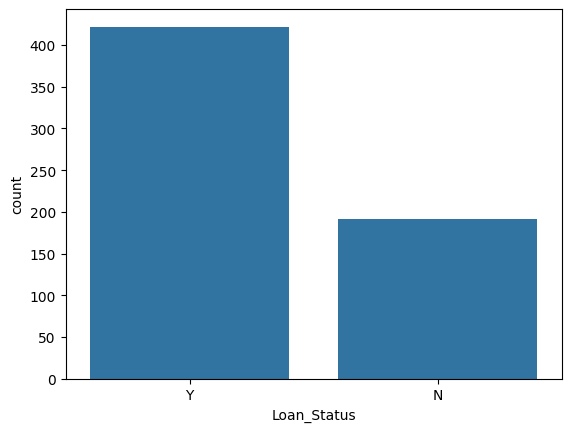

In [ ]:
data['Loan_Status'].value_counts()
sns.countplot(x='Loan_Status', data=data)
plt.show()

In [ ]:
categorical = ['Gender','Married','Dependents','Self_Employed','Credit_History','Loan_Amount_Term']
for col in categorical:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_1273/3112397078.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)
data.isnull().sum()

/tmp/ipykernel_1273/937231135.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace=True)


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
data = data.drop('Loan_ID', axis=1)

In [ ]:
encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = encoder.fit_transform(data[column])

In [ ]:
X = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Decision Tree Accuracy :
0.6910569105691057


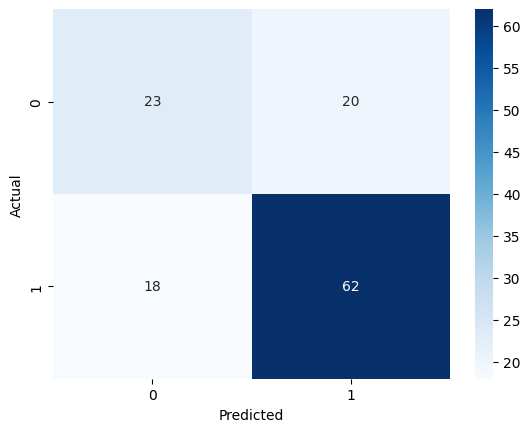

              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123



In [ ]:
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy :")
print(accuracy_score(y_test, dt_pred))
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()
print(classification_report(y_test, dt_pred))

              Feature  Importance
9      Credit_History    0.293493
5     ApplicantIncome    0.244570
7          LoanAmount    0.172321
6   CoapplicantIncome    0.098029
2          Dependents    0.050823
8    Loan_Amount_Term    0.046094
1             Married    0.032243
10      Property_Area    0.029587
4       Self_Employed    0.014453
3           Education    0.011291
0              Gender    0.007095


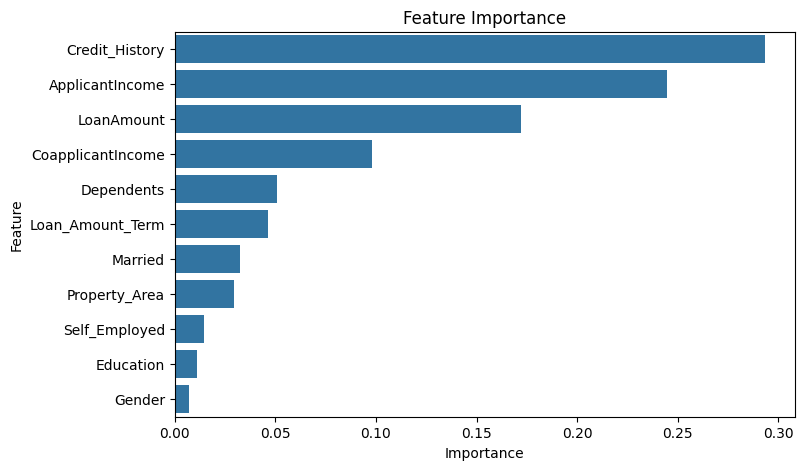

In [ ]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':dt.feature_importances_

})

importance = importance.sort_values(by='Importance',ascending=False)

print(importance)
plt.figure(figsize=(8,5))

sns.barplot(x='Importance',
            y='Feature',
            data=importance)

plt.title("Feature Importance")

plt.show()

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
knn_pred = knn.predict(X_test_scaled)

K-NN Accuracy :
0.7560975609756098


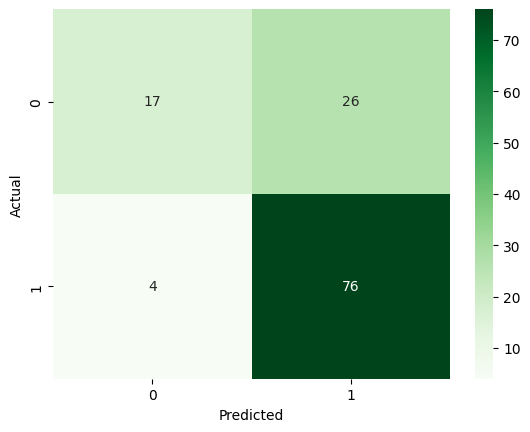

              precision    recall  f1-score   support

           0       0.81      0.40      0.53        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.78      0.67      0.68       123
weighted avg       0.77      0.76      0.73       123



In [ ]:
print("K-NN Accuracy :")
print(accuracy_score(y_test, knn_pred))
cm = confusion_matrix(y_test,knn_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(classification_report(y_test, knn_pred))

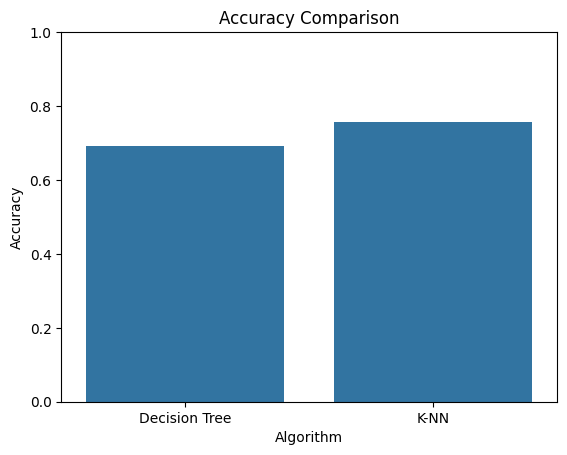

In [ ]:
comparison = pd.DataFrame({
    'Algorithm':['Decision Tree','K-NN'],
    'Accuracy':[accuracy_score(y_test,dt_pred),
                accuracy_score(y_test,knn_pred)]
})
comparison
sns.barplot(x='Algorithm',
            y='Accuracy',
            data=comparison)
plt.ylim(0,1)
plt.title("Accuracy Comparison")
plt.show()